# Table of Contents

<a id="toc"></a>
- [1. Set-up](#1)
    - [1.1 Import Libraries](#1.1)
    - [1.2 Import Data](#1.2)
- [2. Data Visualisation](#2)
    - [2.1 Scatter Plot](#2.1)
    - [2.2 Pair Plot](#2.2)
    - [2.3 Dist Plot](#2.3)
    - [2.4 Box Plot](#2.4)
- [3. Data Split](#3)
- [4. Feature Engineering](#4)
- [5. Model Building](#5)
    - [5.1 KNN](#5.1)
    - [5.2 SVC](#5.2)
    - [5.3 Decision Tree](#5.3)
    - [5.4 Random Forest](#5.4)
    - [5.5 XG Boost](#5.5)
- [6. ModelWise Visualisation](#6)


<a id="1"></a>
# <b>1 <span style='color:#F1A424'>|</span> Set-up</b>

<a id="1.1"></a>
## <b>1.1 <span style='color:#F1A424'>Import Libraries</span></b> 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,confusion_matrix
from warnings import filterwarnings
filterwarnings('ignore')

<a id="1.2"></a>
## <b>1.2 <span style='color:#F1A424'>Import Data</span></b> 

In [2]:
df = pd.read_csv('/kaggle/input/iris/Iris.csv',index_col='Id')
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.Species.value_counts()

Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: Species, dtype: int64

<a id="2"></a>
# <b>2 <span style='color:#F1A424'>|</span> Data Visualisation</b>

<a id="2.1"></a>
## <b>2.1 <span style='color:#F1A424'>Scatter Plot</span></b> 

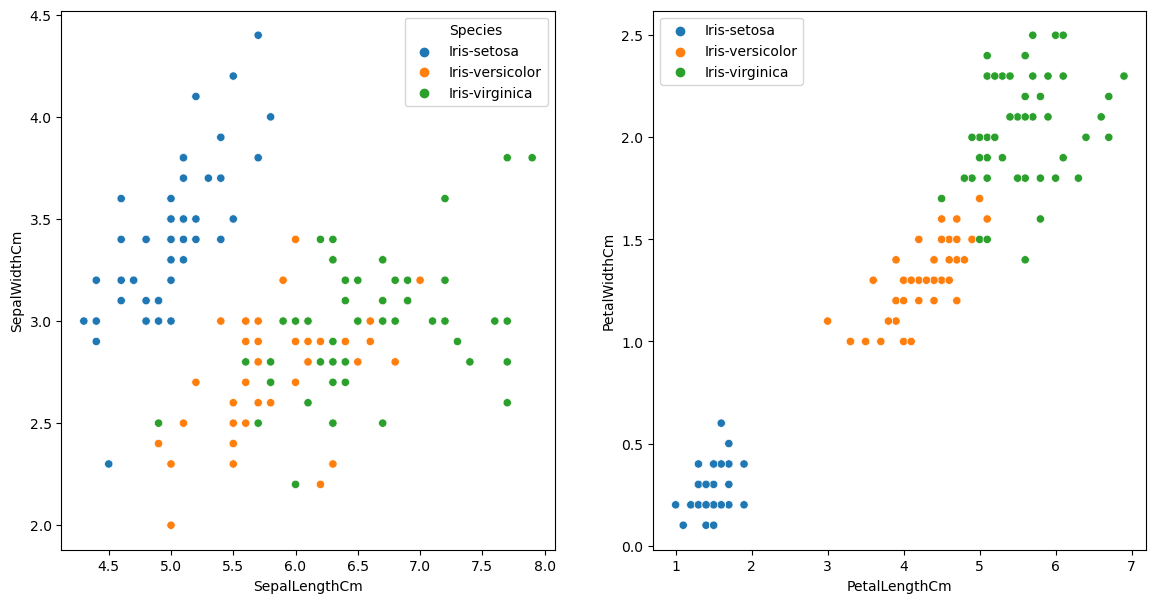

In [4]:
fig,axes = plt.subplots(1,2,figsize=(14.0,7.0))

sns.scatterplot(data = df,x='SepalLengthCm',y='SepalWidthCm',hue='Species',ax=axes[0])
plt.legend()
sns.scatterplot(data = df,x='PetalLengthCm',y='PetalWidthCm',hue='Species',ax=axes[1])
plt.legend()
plt.show()

## Conclusion
### Plot 1
- Species Setosa has smaller sepal lengths but larger sepal widths.
- Versicolor Species lies in the middle of the other two species in terms of sepal length and width
- Species Virginica has larger sepal lengths but smaller sepal widths.

### Plot 2
- Species Setosa has smaller petal lengths and widths.
- Versicolor Species lies in the middle of the other two species in terms of petal length and width
- Species Virginica has the largest of petal lengths and widths.

<a id="2.2"></a>
## <b>2.2 <span style='color:#F1A424'>Pair Plot</span></b> 

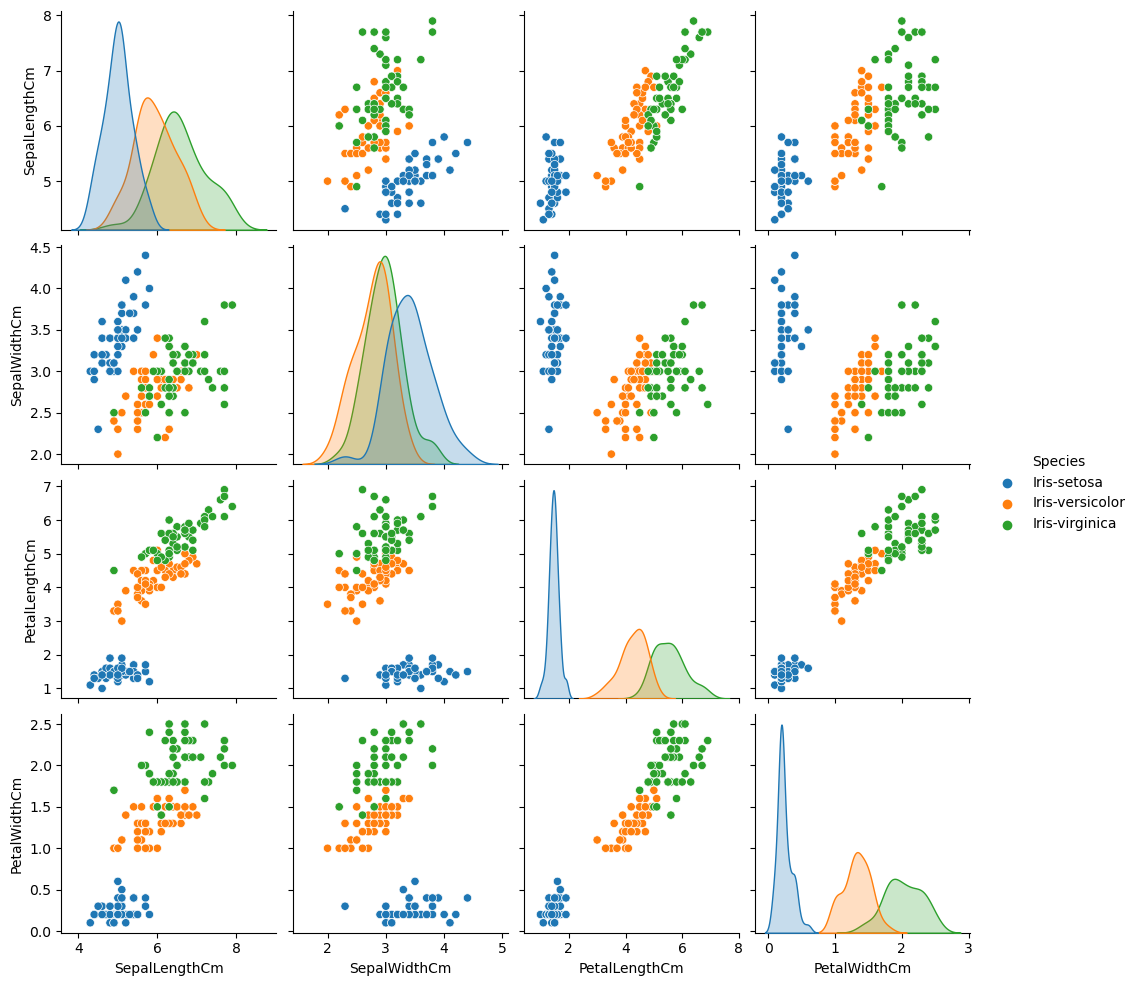

In [5]:
sns.pairplot(df,hue='Species')

## Conclusion
We can see many types of relationships from this plot such as the species Setosa has the smallest of petals widths and lengths. It also has the smallest sepal length but larger sepal widths. Such information can be gathered about any other species.

<a id="2.3"></a>
## <b>2.3 <span style='color:#F1A424'>Dist Plot</span></b> 

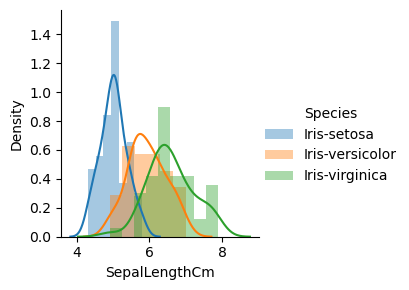

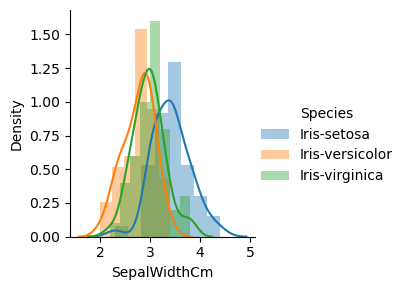

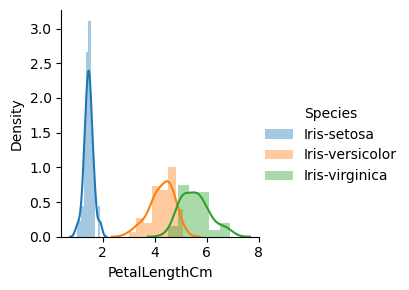

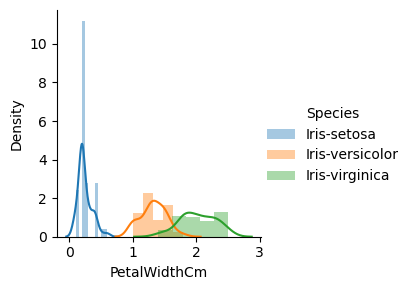

In [6]:
plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.distplot, "SepalLengthCm").add_legend()
 
plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.distplot, "SepalWidthCm").add_legend()
 
plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.distplot, "PetalLengthCm").add_legend()
 
plot = sns.FacetGrid(df, hue="Species")
plot.map(sns.distplot, "PetalWidthCm").add_legend()
 
plt.show()

## Conclusion
- In the case of Sepal Length, there is a huge amount of overlapping.
- In the case of Sepal Width also, there is a huge amount of overlapping.
- In the case of Petal Length, there is a very little amount of overlapping.
- In the case of Petal Width also, there is a very little amount of overlapping.
So we can use Petal Length and Petal Width as the classification feature.

<a id="2.4"></a>
## <b>2.4 <span style='color:#F1A424'>Box Plot</span></b> 

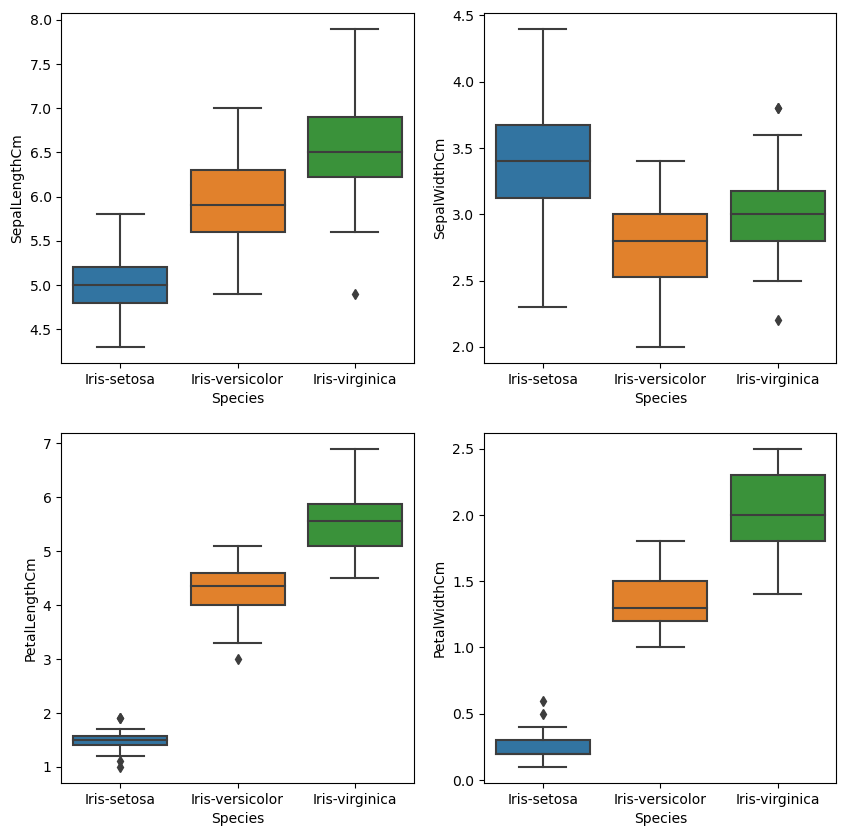

In [7]:
def graph(y):
    sns.boxplot(x="Species", y=y, data=df)
 
plt.figure(figsize=(10,10))
     
# Adding the subplot at the specified
# grid position
plt.subplot(221)
graph('SepalLengthCm')
 
plt.subplot(222)
graph('SepalWidthCm')
 
plt.subplot(223)
graph('PetalLengthCm')
 
plt.subplot(224)
graph('PetalWidthCm')
 
plt.show()

<a id="3"></a>
# <b>3 <span style='color:#F1A424'>|</span> Data Split</b>

In [8]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [9]:
y = y.replace({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})
y = y.values

In [10]:
x = x.drop(['SepalLengthCm','SepalWidthCm'],axis=1)

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(120, 2) (30, 2) (120,) (30,)


<a id="4"></a>
# <b>4 <span style='color:#F1A424'>|</span> Feature Engineering</b>

In [12]:
scaler = StandardScaler()
oe = OrdinalEncoder()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)



<a id="5"></a>
# <b>5 <span style='color:#F1A424'>|</span> Model Building</b>

<a id="5.1"></a>
## <b>5.1 <span style='color:#F1A424'>KNN</span></b> 

In [13]:
knn = KNeighborsClassifier(n_neighbors=5,n_jobs=-1,p=2)
knn.fit(x_train,y_train)
knn_pred = knn.predict(x_test)
print(accuracy_score(y_test,knn_pred))
cm = confusion_matrix(y_test,knn_pred)
cm

1.0


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

<a id="5.2"></a>
## <b>5.2 <span style='color:#F1A424'>SVC</span></b> 

In [14]:
svc = SVC(kernel='rbf')
svc.fit(x_train,y_train)
svc_pred = svc.predict(x_test)
print(accuracy_score(y_test,svc_pred))
cm = confusion_matrix(y_test,svc_pred)
cm

1.0


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

<a id="5.3"></a>
## <b>5.3 <span style='color:#F1A424'>Decision Tree</span></b> 

In [15]:
dt = DecisionTreeClassifier(criterion='entropy')
dt.fit(x_train,y_train)
dt_pred = svc.predict(x_test)
print(accuracy_score(y_test,dt_pred))
cm = confusion_matrix(y_test,dt_pred)
cm

1.0


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

<a id="5.4"></a>
## <b>5.4 <span style='color:#F1A424'>Random Forest</span></b> 

In [16]:
rf = RandomForestClassifier()
rf.fit(x_train,y_train)
rf_pred = rf.predict(x_test)
print(accuracy_score(y_test,rf_pred))
cm = confusion_matrix(y_test,rf_pred)
cm

1.0


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

<a id="5.5"></a>
## <b>5.5 <span style='color:#F1A424'>XG Boost</span></b> 

In [17]:
xgb = XGBClassifier()
xgb.fit(x_train,y_train)
xgb_pred = svc.predict(x_test)
print(accuracy_score(y_test,xgb_pred))
cm = confusion_matrix(y_test,xgb_pred)
cm

1.0


array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

<a id="6"></a>
# <b>6 <span style='color:#F1A424'>|</span> ModelWise Visualisation</b>

In [18]:
def versiontuple(v):
    return tuple(map(int, (v.split("."))))


def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=cmap(idx),
                    marker=markers[idx], label=cl)

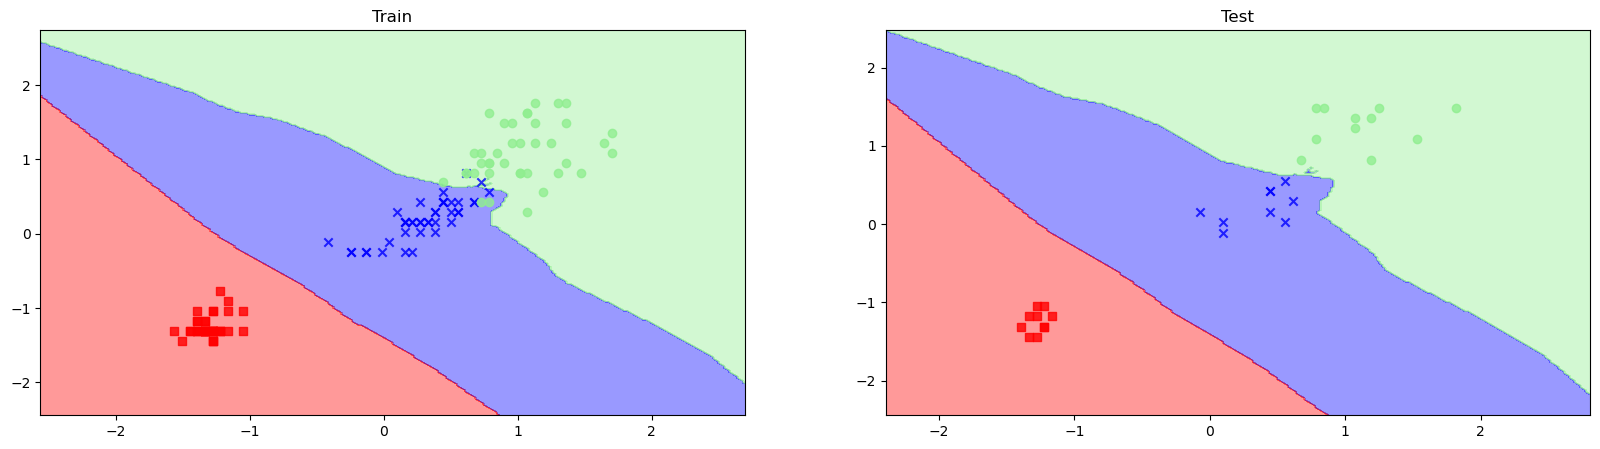

In [19]:
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Train')
plot_decision_regions(x_train,y_train,knn)
plt.subplot(122)
plt.title('Test')
plot_decision_regions(x_test,y_test,knn)
plt.show()

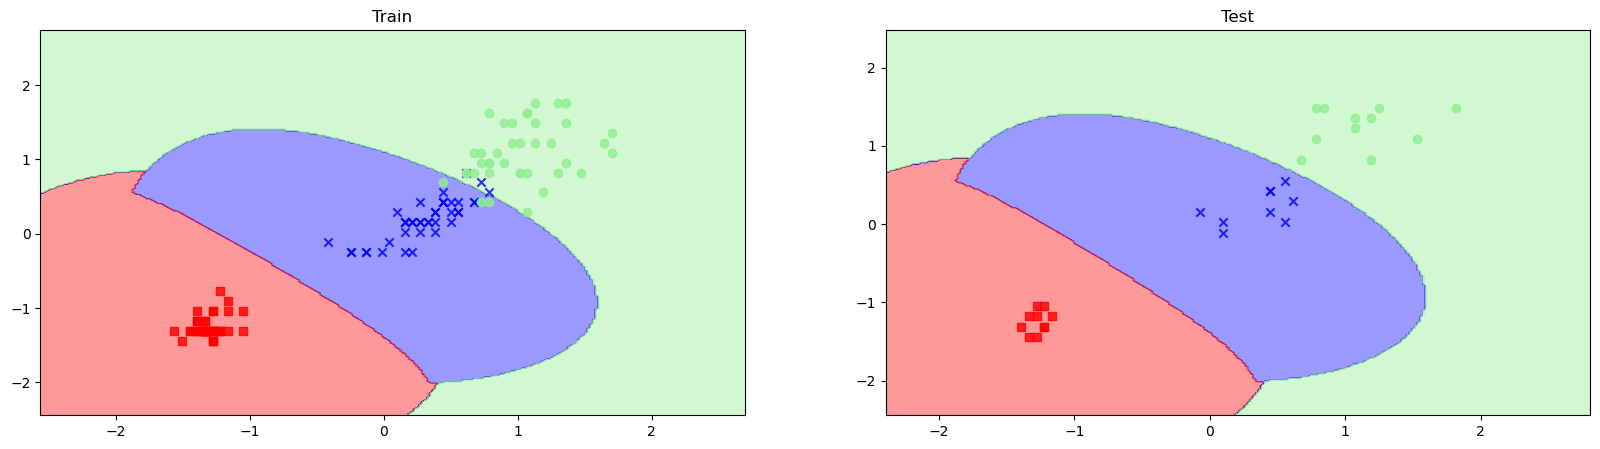

In [20]:
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Train')
plot_decision_regions(x_train,y_train,svc)
plt.subplot(122)
plt.title('Test')
plot_decision_regions(x_test,y_test,svc)
plt.show()

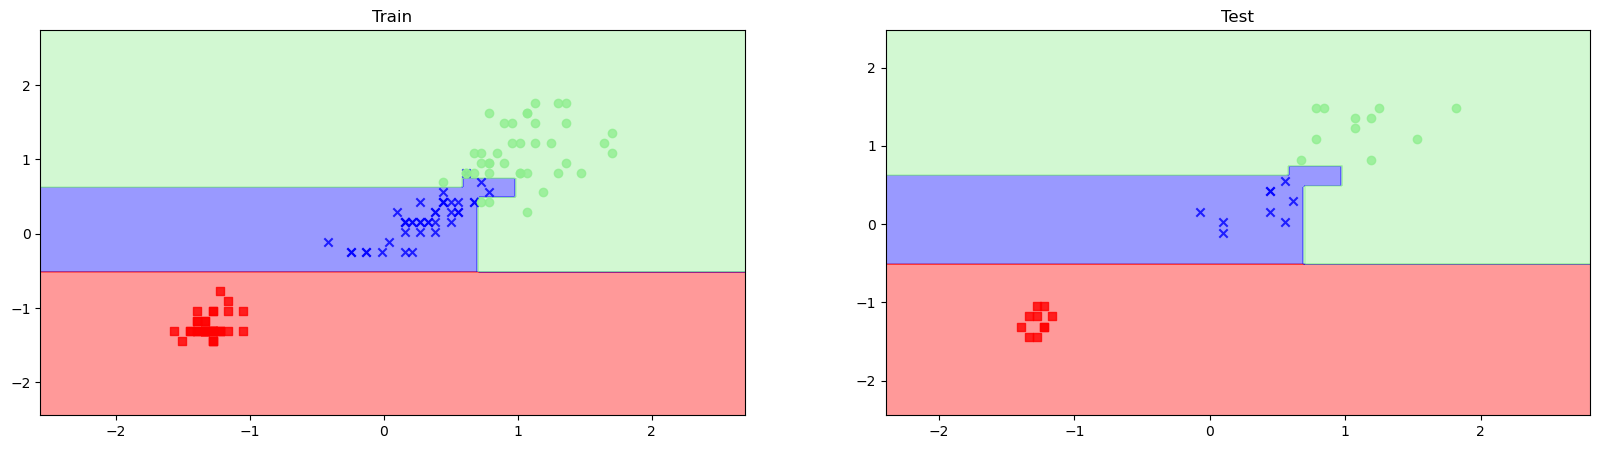

In [21]:
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Train')
plot_decision_regions(x_train,y_train,dt)
plt.subplot(122)
plt.title('Test')
plot_decision_regions(x_test,y_test,dt)
plt.show()

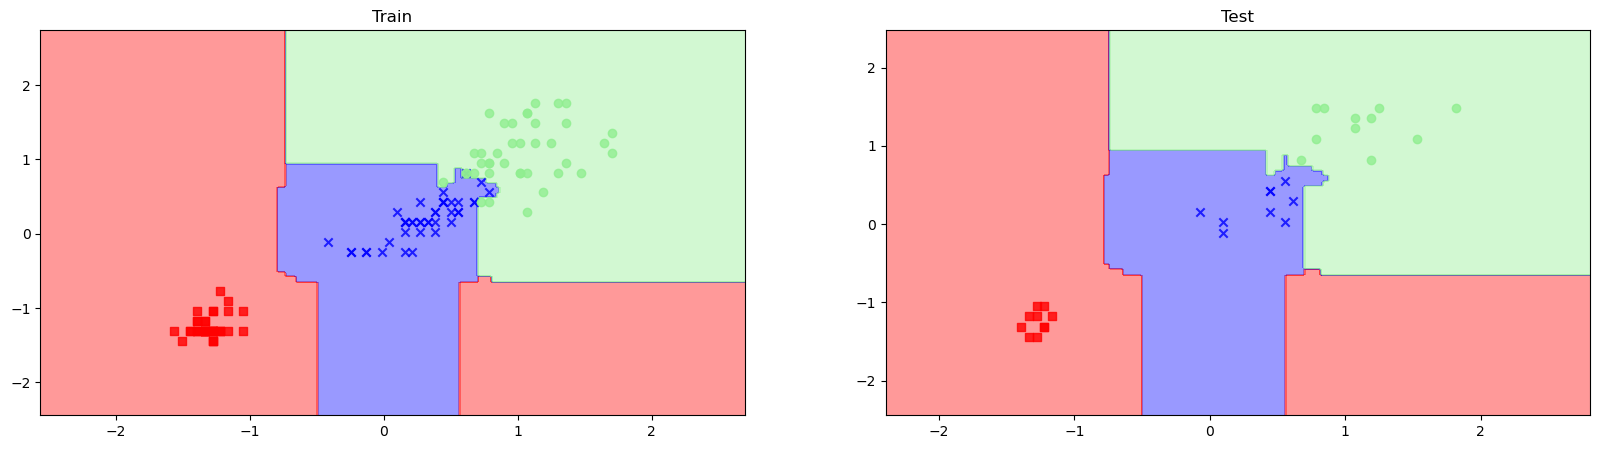

In [22]:
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Train')
plot_decision_regions(x_train,y_train,rf)
plt.subplot(122)
plt.title('Test')
plot_decision_regions(x_test,y_test,rf)
plt.show()

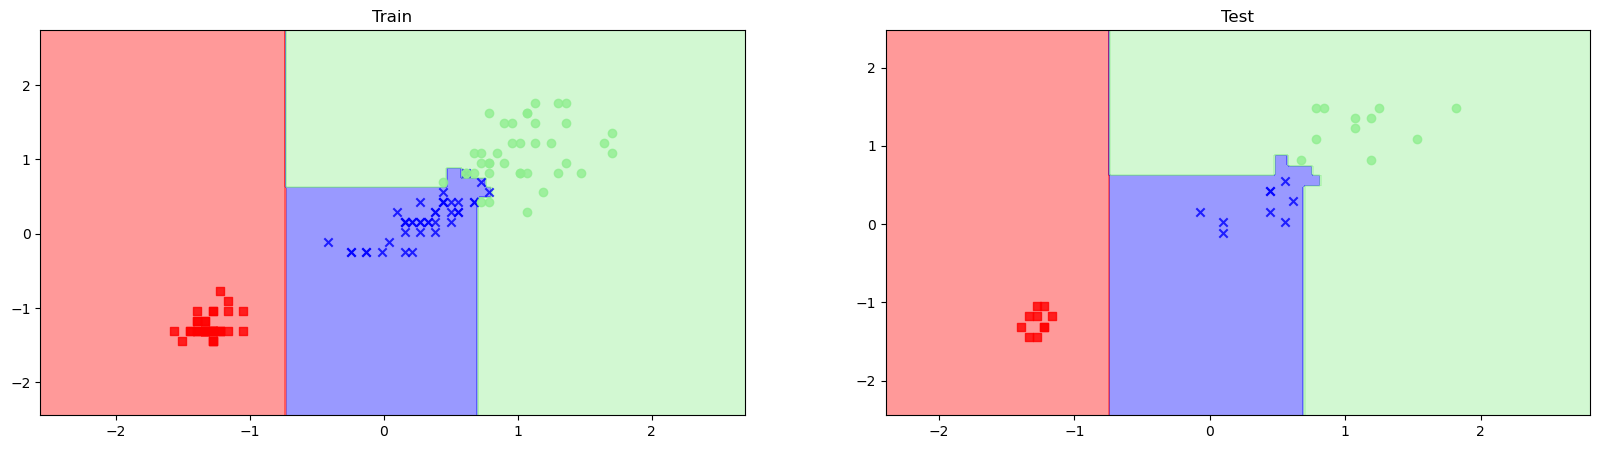

In [23]:
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Train')
plot_decision_regions(x_train,y_train,xgb)
plt.subplot(122)
plt.title('Test')
plot_decision_regions(x_test,y_test,xgb)
plt.show()